Dataset shape: (392, 8)
Training Locally Weighted Regression...

Mean Squared Error: 16.54
R² Score: 0.7278


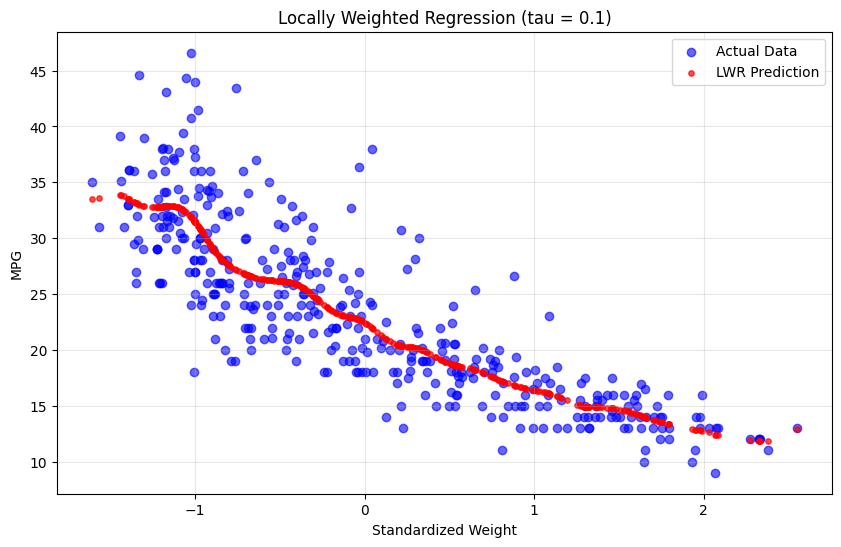

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load the Auto MPG dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
column_names = ['MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight',
                'Acceleration', 'Model Year', 'Origin', 'Car Name']

df = pd.read_csv(url, names=column_names, na_values='?', 
                 comment='\t', sep=' ', skipinitialspace=True)

df = df.drop('Car Name', axis=1)
df = df.dropna()

print("Dataset shape:", df.shape)

# Prepare data
X = np.array(df['Weight']).reshape(-1, 1)
y = np.array(df['MPG'])

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==================== Locally Weighted Regression ====================
tau = 0.1  # Bandwidth parameter (smaller = more local)
y_pred = np.zeros(len(X_scaled))

model = LinearRegression()

print("Training Locally Weighted Regression...")

for i in range(len(X_scaled)):
    # Compute weights for all points relative to current point i
    distances = (X_scaled - X_scaled[i]) ** 2
    weights = np.exp(-distances.ravel() / (2 * tau**2))
    
    # Fit weighted linear regression
    model.fit(X_scaled, y, sample_weight=weights)
    
    # Predict for current point
    y_pred[i] = model.predict(X_scaled[i].reshape(1, -1))[0]

# ==================== Evaluation ====================
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print(f"\nMean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.4f}")

# ==================== Plot ====================
plt.figure(figsize=(10, 6))
plt.scatter(X_scaled, y, color='blue', alpha=0.6, label='Actual Data')
plt.scatter(X_scaled, y_pred, color='red', alpha=0.7, s=15, label='LWR Prediction')
plt.xlabel('Standardized Weight')
plt.ylabel('MPG')
plt.title(f'Locally Weighted Regression (tau = {tau})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

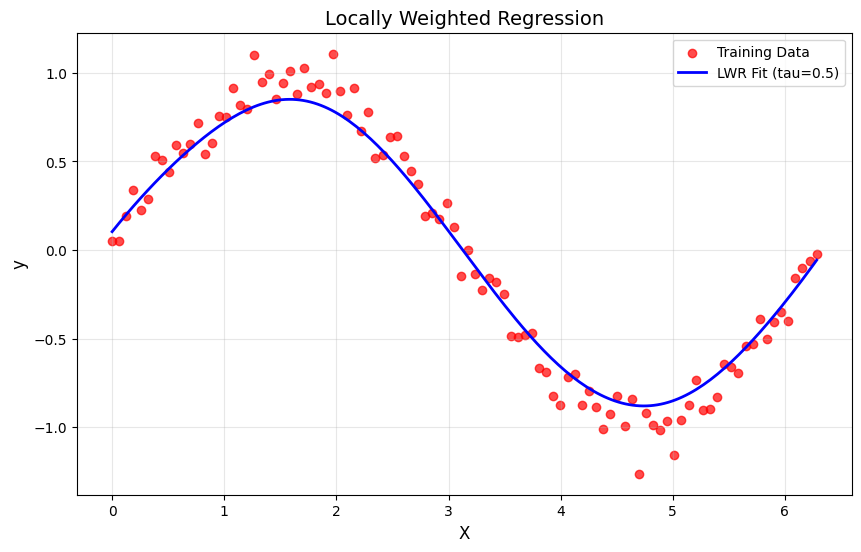

In [10]:
import numpy as np
import matplotlib.pyplot as plt


def gaussian_kernel(x, xi, tau):
    return np.exp(-np.sum((x - xi) ** 2) / (2 * tau ** 2))

def locally_weighted_regression(x, X, y, tau):
    m = X.shape[0]
    weights = np.array([gaussian_kernel(x, X[i], tau) for i in range(m)])
    W = np.diag(weights)
    X_transpose_W = X.T @ W
    theta = np.linalg.inv(X_transpose_W @ X) @ X_transpose_W @ y
    return x @ theta

np.random.seed(42)
X = np.linspace(0, 2 * np.pi, 100)
y = np.sin(X) + 0.1 * np.random.randn(100)
X_bias = np.c_[np.ones(X.shape), X]

x_test = np.linspace(0, 2 * np.pi, 200)
x_test_bias = np.c_[np.ones(x_test.shape), x_test]
tau = 0.5
y_pred = np.array([locally_weighted_regression(xi, X_bias, y, tau) for xi in x_test_bias])

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='red', label='Training Data', alpha=0.7)
plt.plot(x_test, y_pred, color='blue', label=f'LWR Fit (tau={tau})', linewidth=2)
plt.xlabel('X', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Locally Weighted Regression', fontsize=14)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.show()